# Time series prediction using LSTM

## Dataset
- Daily minimum temperatures in Melbourne, Australia, 1981-1990
- Units: Degrees Celcius

## Question 1

### Load the data
- load daily-minimum-temperatures-in-me.csv

In [135]:
# if you are using google colab
from google.colab import files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.layers import LSTM
from keras  import callbacks
from keras import optimizers
import pandas as pd 
import tensorflow as tf
import numpy as np

In [137]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/cb/daily-minimum-temperatures-in-me.csv', index_col='Date')

### Print the data
- First 5 rows only

            Temperature
Date                   
1981-01-01         20.7
1981-01-02         17.9
1981-01-03         18.8
1981-01-04         14.6
1981-01-05         15.8


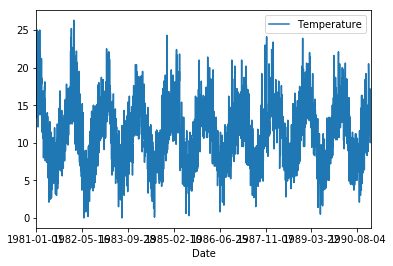

In [139]:
print(df.head())
df.plot()

### Set index column
- Set the DataFrame index using "Date" column

In [140]:
# Data Cleansing
columns_to_keep = ['Temperature']
df = df[columns_to_keep]
df['Temperature'] = df['Temperature'].apply(lambda x: x*1000)
df.index.names = ['Date']
df.sort_index(inplace=True)
print('Total rows: {}'.format(len(df)))
df.head()

Total rows: 3650


,Temperature
Date,
1981-01-01,20700.0
1981-01-02,17900.0
1981-01-03,18800.0
1981-01-04,14600.0
1981-01-05,15800.0


## Question 2

### Check the total count of null values in the data

In [141]:
# Null Values?
df.isnull().sum()
print("no null columns:",df.isnull().sum())

no null columns: Temperature    0
dtype: int64


### Drop all the rows with null values
- use dropna() method

In [0]:
df.dropna(inplace=True)

## Question 3

### Describe your dataframe
- use describe() method

In [143]:
df.describe()

,Temperature
count,3650.000000
mean,11177.753425
std,4071.836899
min,0.000000
25%,8300.000000
50%,11000.000000
75%,14000.000000
max,26300.000000


### Plot the dataframe
- use plot() method

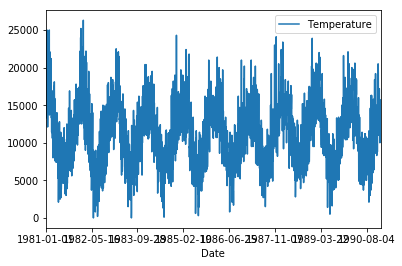

In [144]:
df.plot()

### Get representation of the distribution of data using histogram
- use hist() method

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f5a29412ba8>]],
      dtype=object)

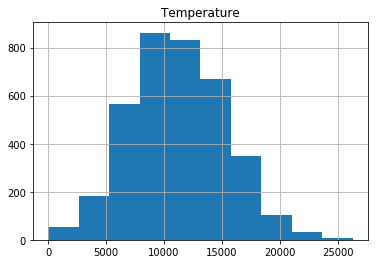

In [145]:
df.hist(bins=10)

### Check minimum and maximum temperature
- use min() and max() methods

In [146]:
# Scaled Data
print('Min', np.min(df))
print('Max', np.max(df))

Min Temperature    0.0
dtype: float64
Max Temperature    26300.0
dtype: float64


In [0]:
df['Temperature'] = df['Temperature']/1000  ### Normalizing the data

## Question 4

### Split the dataset into training and testing
- training data: 75%
- testing data: 25%

In [148]:
dataset = df.astype('float32')
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(dataset)
print('Min', np.min(scaled))
print('Max', np.max(scaled))

Min 0.0
Max 1.0


In [149]:
#Create the model
train_size = int(len(scaled) * 0.75)
print(train_size)
test_size = len(scaled - train_size)
train, test = scaled[0:train_size, :], scaled[train_size: len(scaled), :]
print('train: {}\ntest: {}'.format(len(train), len(test)))
train

2737
train: 2737
test: 913


array([[0.7870723 ],
       [0.68060837],
       [0.71482889],
       ...,
       [0.25475285],
       [0.35741444],
       [0.35361218]])

### Normalize the data
- normalize temperature values using MinMaxScaler
- feature_range: 0-1
- fit MinMaxScaler on train data and transform it
  - use fit_transform() method
- transform test data using MinMaxScaler object
  - use transform() method

### Print scaled train and test data
- print only first 5 values

In [150]:
print(scaled_train[:5])

[[0.78707224]
 [0.68060837]
 [0.7148289 ]
 [0.55513308]
 [0.60076046]]


In [151]:
print(scaled_test[:5])

[[0.23504274]
 [0.22649573]
 [0.18803419]
 [0.19230769]
 [0.33760684]]


## Question 5

### Create sequential data
Map the temperature at a particular day 'd' to the temperature at day t
'd+n', where n is any number you define.

For example: to map temperatures of consecutive days, use d+1, i.e. lookback = 1
- Below function takes data as input and returns sequential data.
- X as features and y as labels

In [0]:
import numpy as np
def create_seq_data(data, lookback=1):
  X, y = list(), list()
  
  for day in range((len(data)-lookback)):
    X.append(data[day: day+lookback, 0])
    y.append(data[day+lookback, 0])
  return np.array(X), np.array(y)

### Use the above function to create train and test sets
- Get X_train and y_train
- Get X_test and y_test
- lookback = 1

In [0]:
look_back = 1
X_train, y_train = create_seq_data(train, look_back)
X_test, y_test = create_seq_data(test, look_back)

### Reshape the data
- Reshape X_train and X_test
- use np.reshape() method
- this is to be done to make the data ready for input in model

In [0]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

### Print shape of data
- print shape of X_train and X_test

In [155]:
print(X_train.shape)
print(X_test.shape)

(2736, 1, 1)
(912, 1, 1)


## Question 6

### Define sequential model
- initialize a Sequential model
- add an LSTM layer
  - units: 10
  - stateful: True
  - pass a `batch_input_shape` argument to your layer
  - batch_input_shape: (batch_size, look_back, 1)
    - batch_size: 1
    - look_back: 1
- add Dense layer with 1 neuron

In [0]:
#The network has a visible layer with 1 input, a hidden layer with 4 LSTM blocks or neurons, and an output layer that makes a single value prediction. The default sigmoid activation function is used for the LSTM blocks. The network is trained for 100 epochs and a batch size of 1 is used.
#create and fit the LSTM network
batch_size = 1
model = Sequential()
model.add(LSTM(10, batch_input_shape=(batch_size, look_back, 1), stateful=True))
model.add(Dense(1))

## Question 7

### compile your model
- loss: mean_squared_error
- optimizer: adam

In [0]:
model.compile(loss='mean_squared_error', optimizer='adam')

### summarize your model
- use summary() method

In [158]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_5 (LSTM)                (1, 10)                   480       
_________________________________________________________________
dense_5 (Dense)              (1, 1)                    11        
Total params: 491
Trainable params: 491
Non-trainable params: 0
_________________________________________________________________


## Question 8

### fit your model
- epochs: 50
- batch_size: 1

In [159]:
model.fit(X_train, y_train, epochs=50, batch_size=batch_size, verbose=2, shuffle=True)

Epoch 1/50
 - 5s - loss: 0.0227
Epoch 2/50
 - 4s - loss: 0.0131
Epoch 3/50
 - 4s - loss: 0.0110
Epoch 4/50
 - 4s - loss: 0.0106
Epoch 5/50
 - 5s - loss: 0.0103
Epoch 6/50
 - 4s - loss: 0.0103
Epoch 7/50
 - 4s - loss: 0.0101
Epoch 8/50
 - 4s - loss: 0.0101
Epoch 9/50
 - 4s - loss: 0.0101
Epoch 10/50
 - 4s - loss: 0.0101
Epoch 11/50
 - 4s - loss: 0.0101
Epoch 12/50
 - 5s - loss: 0.0100
Epoch 13/50
 - 4s - loss: 0.0100
Epoch 14/50
 - 4s - loss: 0.0100
Epoch 15/50
 - 4s - loss: 0.0100
Epoch 16/50
 - 4s - loss: 0.0100
Epoch 17/50
 - 4s - loss: 0.0101
Epoch 18/50
 - 4s - loss: 0.0101
Epoch 19/50
 - 5s - loss: 0.0101
Epoch 20/50
 - 5s - loss: 0.0100
Epoch 21/50
 - 5s - loss: 0.0101
Epoch 22/50
 - 4s - loss: 0.0099
Epoch 23/50
 - 4s - loss: 0.0101
Epoch 24/50
 - 4s - loss: 0.0100
Epoch 25/50
 - 4s - loss: 0.0101
Epoch 26/50
 - 6s - loss: 0.0101
Epoch 27/50
 - 7s - loss: 0.0101
Epoch 28/50
 - 7s - loss: 0.0100
Epoch 29/50
 - 7s - loss: 0.0100
Epoch 30/50
 - 7s - loss: 0.0101
Epoch 31/50
 - 6s -

## Question 9

### make predictions on train data
- use predict() method
  - batch_size: 1
- store predictions in a variable

### reset model state
- if you are using stateful=True in your model then you should call reset_states every time, when you want to make consecutive model calls independent.
- use reset_states() method

In [0]:
model.reset_states()
trainPredict = model.predict(X_train, batch_size=batch_size)

### make predictions on test data
- use predict() method
  - batch_size: 1
- store predictions in a variable

In [0]:
model.reset_states()
testPredict = model.predict(X_test, batch_size=batch_size)

## Question 10

### Inverse train predictions and true labels
- use your MinMaxSclarer object
- use inverse_transform() method

In [0]:
trainPredict = scaler.inverse_transform(trainPredict)
y_train = scaler.inverse_transform([y_train])




### Inverse test predictions and true labels
- use your MinMaxSclarer object
- use inverse_transform() method

In [0]:
model.reset_states()
testPredict = scaler.inverse_transform(testPredict)
y_test = scaler.inverse_transform([y_test])


### Evaluate train predictions
- calculate RMSE
- RMSE = sqrt(mean_squared_error(true_labels, predicted_labels))
- use sqrt() and mean_squared_error() method
- print training RMSE

In [164]:
import math
from sklearn.metrics import mean_squared_error
# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))



Train Score: 2.67 RMSE


### Evaluate test predictions
- calculate RMSE
- RMSE = sqrt(mean_squared_error(true_labels, predicted_labels))
- use sqrt() and mean_squared_error() method
- print testing RMSE

In [165]:
import math
from sklearn.metrics import mean_squared_error
testScore = math.sqrt(mean_squared_error(y_test[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Test Score: 2.59 RMSE
